# Puzzle Velocity Analysis — Day Seven

*Same question as [day six](day-six-analysis.ipynb): is the lccjs microtask estimator any good?*

**Day-seven upgrades:**
- Data source: still SQLite (`~/.lccjs/lccjs.db`) — no pipeline change
- Full re-run on updated dataset (current counts in §0), including 06-03 session data
- 🆕 §2: 7-day window (06-03 bucket added)
- 🆕 §3: agent roster updated — all agents grew; GRAPE joined
- 🆕 §6: ELDERBERRY task-mix drill-down — re-run on expanded dataset — does its high median persist after controlling for role?
- All normalization in-memory; DB is never mutated


<details>
<summary><strong>New here? — project orientation (click to expand)</strong></summary>

This notebook analyses the **lccjs puzzle-velocity log** — a per-task time record that tracks how long Claude actually takes to close GitHub issues vs. how long it predicted. Two estimates are recorded per task: **H** (the human's time budget, enforces Yegor's ≤60m hard cap) and **C** (Claude's own forward-looking wall-clock prediction, used for calibration). `c_ratio = c_min / actual_min` — values above 1 mean Claude over-estimated (task finished faster than predicted). **Agents** (APPLE, BANANA, CHERRY, DRAGONFRUIT, ELDERBERRY, FIG) are named Claude sessions, each working an isolated git worktree of the same repo. The goal: understand whether predictions are systematically biased, and whether they improve over time.

</details>

> **Stats vocabulary:** unfamiliar with KW, MWU, bootstrap CI, or Spearman ρ? See [docs/glossary/stats-analysis.md](../docs/glossary/stats-analysis.md) for plain-language explanations of every statistical term used in this notebook.

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:
DB = Path.home() / ".lccjs" / "lccjs.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Day-seven ceiling: restrict to rows through 2026-06-03 HST so re-execution stays reproducible
df = df[df["hst_day"] <= '2026-06-03'].copy()
df["agent"]    = df["agent"].fillna("").astype(str).str.strip()
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")

Total rows from DB : 534
Calibration-usable : 439  (c_min + actual_min > 0)


In [3]:
def bootstrap_ci(series, n=10_000):
    """Bootstrap 95% CI for the median (uses module-level rng)."""
    vals = np.asarray(series)
    samples = [np.median(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n)]
    return np.percentile(samples, [2.5, 97.5])

## Key concept: `c_ratio`

`c_ratio = c_min / actual_min` — the ratio of Claude's time prediction to actual wall-clock.

- **> 1.0** — estimated high: Claude predicted it would take longer than it did (the typical case)
- **= 1.0** — perfect: prediction matched actuals exactly
- **< 1.0** — underestimated: actual time exceeded the prediction

The median `c_ratio` across all calibration-usable rows is the primary calibration metric. A value of 3× means Claude budgets roughly three times as long as the task actually takes. `c_min` is set *before* starting work; rows missing either `c_min` or `actual_min` are excluded from calibration analysis.

## Key concept: calibration-usable rows

A row is **calibration-usable** if it has both a `c_min` (Claude's pre-task time estimate) and an `actual_min > 0` (measured wall-clock). Rows missing either are excluded from all ratio analysis.

**Why rows drop out:**
- `c_min` absent — task predates the C-estimate protocol, or was a spontaneous PM/triage turn with no advance prediction
- `actual_min` absent or zero — timestamps not captured, or the row was logged retroactively without timing data

Excluded rows still appear in role/agent distribution counts in §0 — only calibration sections (§1–§6) operate on the usable subset. §0 prints both totals so the drop is visible.

## 0. Data provenance & cleanliness

In [4]:
# Role / agent / model distributions as styled DataFrames; missing-data bar chart
role_ct = df["role"].replace("", "(none)").value_counts().rename_axis("role").reset_index(name="n")
display(role_ct.style.set_caption("Role distribution (all DB rows)").hide(axis="index"))

agent_ct = df["agent"].replace("", "(none)").value_counts().rename_axis("agent").reset_index(name="n")
display(agent_ct.style.set_caption("Agent distribution (all DB rows)").hide(axis="index"))

model_ct = df["model"].fillna("").replace("", "(none)").value_counts().rename_axis("model").reset_index(name="n")
display(model_ct.style.set_caption("Model distribution — post in-memory normalization").hide(axis="index"))

# Missing-data summary with bar to make model-null rate visually prominent
missing_rows = []
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    total = null_ct + empty_ct
    missing_rows.append({"column": col, "missing": total, "of_total": len(df),
                          "pct_missing": round(100 * total / len(df), 1)})
missing_df = pd.DataFrame(missing_rows)
display(missing_df.style
        .set_caption("Missing data summary")
        .bar(subset=["pct_missing"], color="#d65f5f", vmin=0, vmax=100)
        .hide(axis="index"))

# Flag any model-naming violations that needed in-memory repair
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"NOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template.")

role,n
DEV,173
WRITER,130
RESEARCH,103
PM,39
DATA,30
ARC,17
TEST,17
COMBO,9
SPIKE,7
CHORE,6


agent,n
APPLE,108
BANANA,89
CHERRY,89
DRAGONFRUIT,75
ELDERBERRY,75
(none),46
FIG,46
fig,4
GRAPE,2


model,n
sonnet-4.6,380
(none),128
opus-4.8,25
haiku-4.5,1


column,missing,of_total,pct_missing
actual_min,75,534,14.000000
c_min,32,534,6.000000
h_min,29,534,5.400000
started_iso,77,534,14.400000
finished_iso,43,534,8.100000
model,128,534,24.000000


**Note on role counts:** §0 shows total rows per role; calibration sections (§1–§6) operate on the **calibration-usable subset** (rows with both `c_min` and `actual_min > 0`). PM tasks are often spontaneous triage or issue-filing turns that start without a C-estimate — roughly half of all PM rows predate or skip the prediction step, so they have no `c_min` and are excluded from ratio analysis.

## 1. The robust finding — re-run on calibration-usable rows

Day-six established: **296/318 tasks (93.1%) ran faster than the C-estimate** (sign-test p = 9.67×10⁻⁶³, median 3.33× [3.00–3.75]).
Re-running on the calibration-usable subset to see if the picture holds with 06-02 data added.

Calibration rows   : 439
Ran faster than C  : 408/439  (92.9%)
Sign-test p-value  : 2.58e-85
Median C-ratio     : 3.50×  [95% CI 3.12–3.92]

Day-6 baseline     : 296/318 (93.1%), median 3.33× [3.00–3.75]


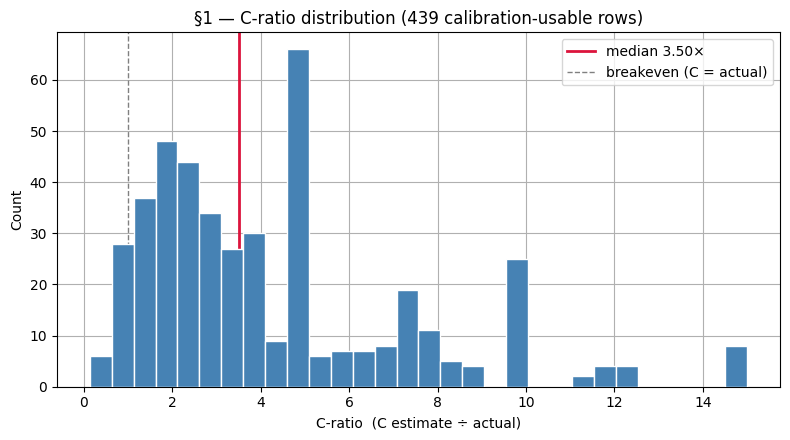

In [5]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

lo, hi = bootstrap_ci(cal["c_ratio"])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-6 baseline     : 296/318 (93.1%), median 3.33× [3.00–3.75]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 🆕 Per-day calibration drift — 6-day window (addresses #208)

Day-six found a **non-monotone** pattern across 6 days (2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00×) with no statistically significant learning curve. Day-six adds a sixth bucket (06-02) and re-tests.

       day   n  median   lo   hi
2026-05-28  36    2.51 2.21 3.11
2026-05-29  32    5.00 3.06 6.88
2026-05-30  38    3.34 2.76 4.29
2026-05-31  53    2.67 2.50 5.00
2026-06-01 117    3.33 3.00 3.75
2026-06-02  40    5.00 3.50 5.50
2026-06-03 122    4.00 3.33 5.00

Spearman ρ = 0.396,  p = 0.379  (n_days = 7)
→ No statistically significant monotone trend detected (p ≥ 0.05).
  ⚠ Underpowered: with only 7 day-buckets, Spearman has ~5% power to detect
  anything short of a perfect monotone. Result is uninformative — not a negative
  finding. Revisit when n_days ≥ 10.


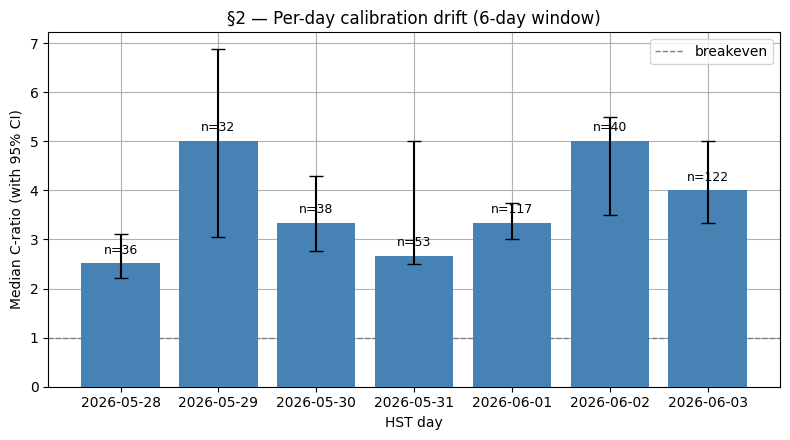

In [6]:
day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    lo_d, hi_d = bootstrap_ci(cr, n=5_000)
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {len(day_df)})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend detected (p ≥ 0.05).")
    print("  ⚠ Underpowered: with only {n_days} day-buckets, Spearman has ~5% power to detect".format(n_days=len(day_df)))
    print("  anything short of a perfect monotone. Result is uninformative — not a negative")
    print("  finding. Revisit when n_days ≥ 10.")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title("§2 — Per-day calibration drift (6-day window)")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Role-by-day composition check — does task mix vary enough to confound the drift claim?
role_day = (cal.groupby("hst_day")["role"]
              .value_counts()
              .unstack(fill_value=0)
              .reindex(sorted(cal["hst_day"].dropna().unique())))
display(role_day.style
        .set_caption("§2 — Role composition per day (calibration-usable rows)")
        .background_gradient(axis=None, cmap="Blues"))
print("Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,")
print("the per-day median reflects mix, not time-based drift.")

role,ARC,CHORE,COMBO,DATA,DEV,PM,RESEARCH,REVIEW,SPIKE,TEST,WRITER
hst_day,,,,,,,,,,,
2026-05-28,4,0,1,0,16,0,0,0,0,1,14
2026-05-29,0,0,1,2,4,0,3,0,4,9,9
2026-05-30,1,0,2,1,10,5,10,0,0,5,4
2026-05-31,0,0,0,6,8,9,7,0,0,1,22
2026-06-01,6,3,2,11,43,1,29,0,2,0,20
2026-06-02,2,0,2,1,10,0,8,1,0,0,16
2026-06-03,3,2,0,6,54,7,24,1,0,1,24


Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,
the per-day median reflects mix, not time-based drift.


**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock.

**05-29 CI anomaly:** day 05-29 showed an unusually wide bootstrap CI [3.17–6.88] in day-five. This remains a caution flag: either a few extreme-ratio outliers, longer inter-turn idle gaps, or genuine within-day volatility. Treat the 05-29 median as less reliable than other buckets.

## 3. Per-agent calibration — re-run on full dataset

Day-six finding: agents differ but **Kruskal-Wallis went non-significant** (H = 3.53, p = 0.619) — agent medians stable. All agents grew today (06-03); GRAPE joined with first row.

      agent  n  median
        FIG 41    2.50
DRAGONFRUIT 53    2.82
     CHERRY 73    3.00
     BANANA 71    3.75
      APPLE 88    4.00
      GRAPE  2    4.29
        fig  4    4.38
 ELDERBERRY 68    5.00

Kruskal-Wallis (agents n≥2, 8 groups): H = 5.35,  p = 0.6176


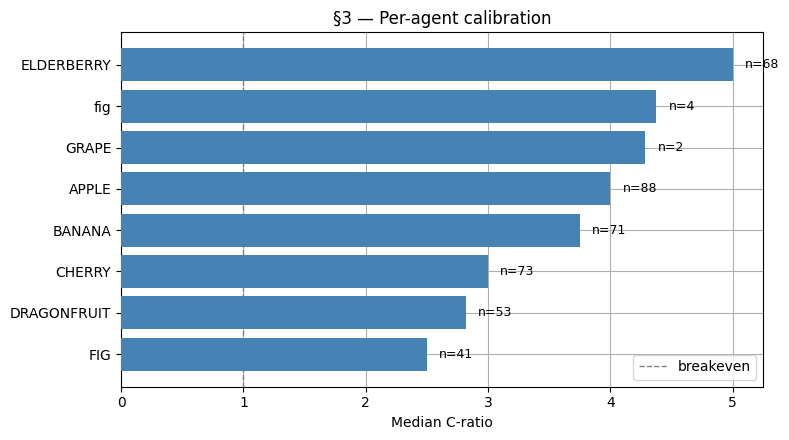

In [8]:
ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

# Exclude singletons (n=1) from KW
kw_agents = agent_df[agent_df["n"] >= 2]["agent"]
groups = [ag[ag["agent"] == a]["c_ratio"].values for a in kw_agents]
agent_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (agents n≥2, {len(kw_agents)} groups): H = {agent_kw.statistic:.2f},  p = {agent_kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()

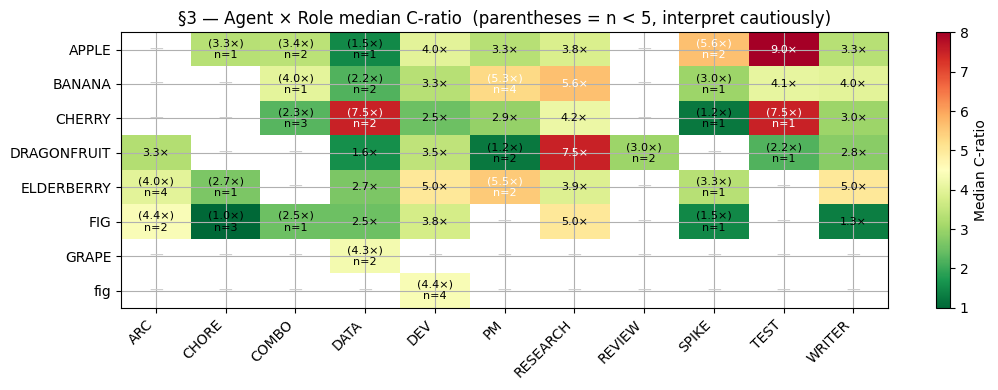

In [9]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as directional only.

    role   n  median  small_n
    TEST  17    5.06    False
RESEARCH  81    4.29    False
  WRITER 109    3.60    False
     ARC  16    3.46    False
   COMBO   8    3.40    False
      PM  22    3.38    False
     DEV 146    3.28    False
   SPIKE   6    3.17     True
  REVIEW   2    3.02     True
    DATA  27    2.43    False
   CHORE   5    1.25     True


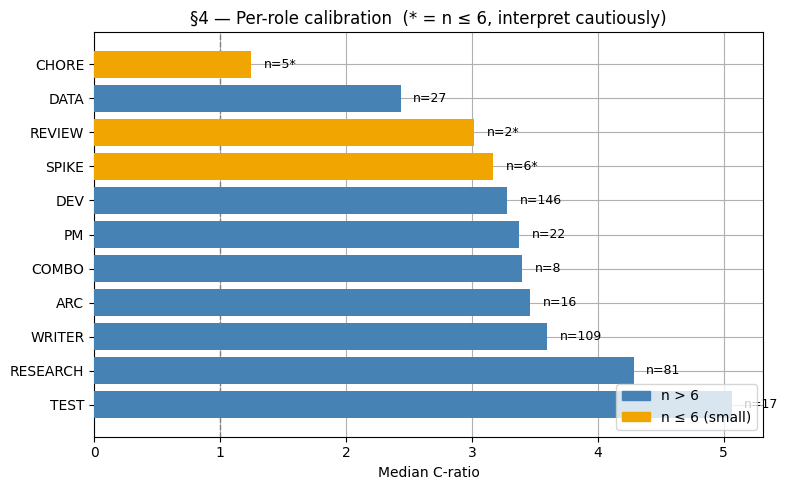

In [10]:
role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr)})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
role_df["small_n"] = role_df["n"] <= 6
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()

## 5. Model-stratified calibration

Rows with a populated `model` column split below; only calibration-usable rows included. Day-six: sonnet-4.6 n=196, 3.75×; opus-4.8 n=16, 2.50×. Checking if opus-4.8 has crossed n ≥ 20.

Calibration-usable rows with model: 332
model
sonnet-4.6    316
opus-4.8       16

      model   n  median
sonnet-4.6 316    3.88
  opus-4.8  16    2.50

Kruskal-Wallis (models with n≥2): H = 3.36,  p = 0.0668
CAVEAT: n is small — result is preliminary.


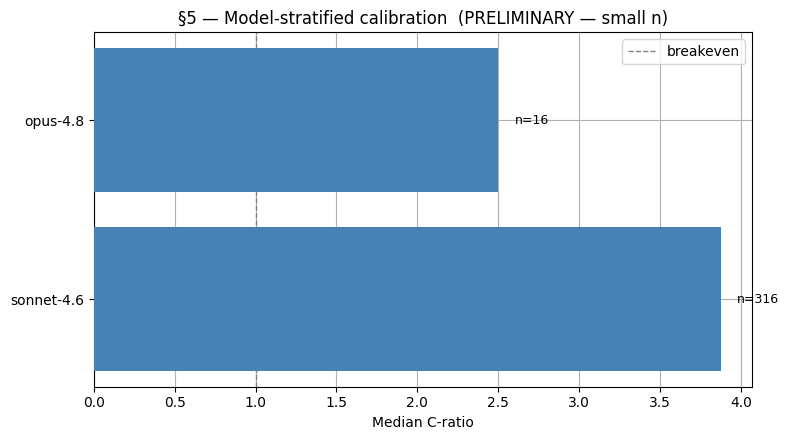

In [11]:
mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 🆕 ELDERBERRY task-mix drill-down (deferred from day-six)

Day-six confirmed ELDERBERRY at 5.00× — the highest-median agent. Re-running on the expanded day-seven dataset. This section asks: **is ELDERBERRY's high median explained by role composition, or does it persist within roles?**

In [12]:
eb = ag[ag["agent"] == "ELDERBERRY"].copy()
print(f"ELDERBERRY calibration-usable rows: {len(eb)}")
print()

# Role distribution for ELDERBERRY vs. fleet
eb_role = eb["role"].value_counts().rename("ELDERBERRY")
fleet_role = ag[ag["agent"] != "ELDERBERRY"]["role"].value_counts().rename("Fleet (others)")
role_compare = pd.concat([eb_role, fleet_role], axis=1).fillna(0).astype(int)
role_compare["EB_pct"]    = (role_compare["ELDERBERRY"]    / role_compare["ELDERBERRY"].sum()    * 100).round(1)
role_compare["Fleet_pct"] = (role_compare["Fleet (others)"] / role_compare["Fleet (others)"].sum() * 100).round(1)
display(role_compare.style.set_caption("§6 — ELDERBERRY vs. fleet role distribution").background_gradient(axis=None, cmap="Blues", subset=["ELDERBERRY", "Fleet (others)"]))

print()

# Per-role median + Mann-Whitney U tests for ELDERBERRY vs. fleet
within_rows = []
for role in sorted(eb["role"].unique()):
    eb_cr = eb[eb["role"] == role]["c_ratio"].values
    fleet_cr = ag[(ag["agent"] != "ELDERBERRY") & (ag["role"] == role)]["c_ratio"].values
    row = {
        "role": role,
        "EB_n": len(eb_cr),
        "EB_median": round(np.median(eb_cr), 2) if len(eb_cr) else None,
        "Fleet_n": len(fleet_cr),
        "Fleet_median": round(np.median(fleet_cr), 2) if len(fleet_cr) else None,
        "U": None, "p_mwu": None, "underpowered": None,
    }
    if len(eb_cr) >= 2 and len(fleet_cr) >= 2:
        u_stat, p_val = stats.mannwhitneyu(eb_cr, fleet_cr, alternative="two-sided")
        row["U"] = round(u_stat, 1)
        row["p_mwu"] = round(p_val, 4)
        row["underpowered"] = (len(eb_cr) < 5) or (len(fleet_cr) < 5)
    else:
        row["underpowered"] = True
    within_rows.append(row)
within_df = pd.DataFrame(within_rows)
print(within_df[["role","EB_n","EB_median","Fleet_n","Fleet_median","U","p_mwu","underpowered"]].to_string(index=False))
print()
print("Note: underpowered = n < 5 in either group; U-test omitted for singletons.")

print()
print(f"ELDERBERRY overall median: {np.median(eb['c_ratio'].values):.2f}×")
fleet_all = ag[ag['agent'] != 'ELDERBERRY']['c_ratio']
print(f"Fleet overall median:      {np.median(fleet_all.values):.2f}×")

ELDERBERRY calibration-usable rows: 68



,ELDERBERRY,Fleet (others),EB_pct,Fleet_pct
role,,,,
WRITER,26,66,38.200000,19.900000
DEV,13,117,19.100000,35.200000
RESEARCH,12,69,17.600000,20.800000
DATA,9,18,13.200000,5.400000
ARC,4,8,5.900000,2.400000
PM,2,20,2.900000,6.000000
SPIKE,1,5,1.500000,1.500000
CHORE,1,4,1.500000,1.200000
TEST,0,16,0.000000,4.800000



    role  EB_n  EB_median  Fleet_n  Fleet_median      U  p_mwu  underpowered
     ARC     4       4.00        8          3.29   21.5 0.3949          True
   CHORE     1       2.67        4          1.12    NaN    NaN          True
    DATA     9       2.67       18          2.03   99.5 0.3537         False
     DEV    13       5.00      117          3.33  842.0 0.5286         False
      PM     2       5.50       20          3.38   27.0 0.4571          True
RESEARCH    12       3.88       69          4.76  361.0 0.4848         False
   SPIKE     1       3.33        5          3.00    NaN    NaN          True
  WRITER    26       5.00       66          3.10 1039.5 0.1141         False

Note: underpowered = n < 5 in either group; U-test omitted for singletons.

ELDERBERRY overall median: 5.00×
Fleet overall median:      3.48×


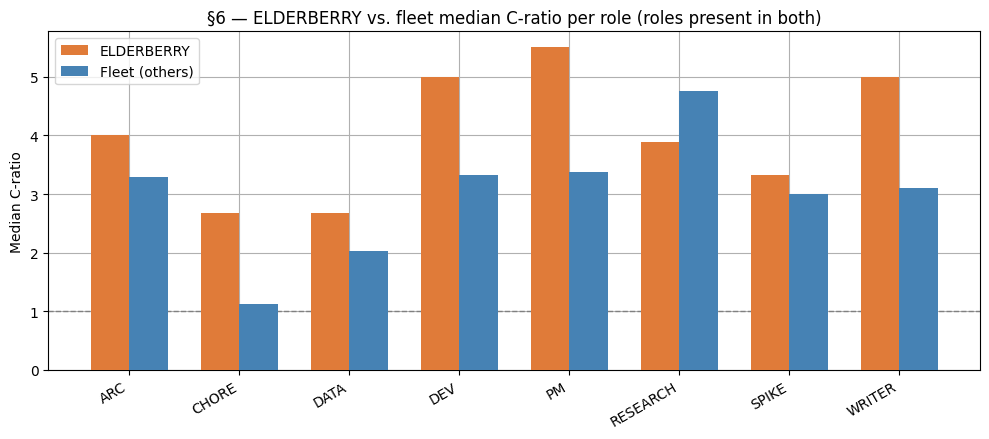

In [13]:
# Side-by-side bar: ELDERBERRY vs. fleet median per role
plot_df = within_df.dropna(subset=["EB_median", "Fleet_median"])
if len(plot_df) > 0:
    x = np.arange(len(plot_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - w/2, plot_df["EB_median"],    w, label="ELDERBERRY", color="#e07b39", zorder=3)
    ax.bar(x + w/2, plot_df["Fleet_median"], w, label="Fleet (others)", color="steelblue", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["role"], rotation=30, ha="right")
    ax.axhline(1.0, color="grey", ls="--", lw=1)
    ax.set_ylabel("Median C-ratio")
    ax.set_title("§6 — ELDERBERRY vs. fleet median C-ratio per role (roles present in both)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No roles with data in both ELDERBERRY and fleet — skipping comparison plot.")

## 7. Takeaways — day seven

### What we can now say

**§1 — Core finding holds at 439 rows.**
Re-run on **439 calibration-usable rows**: **408/439 (92.9%)** ran faster than the C-estimate
(sign-test p = 2.58×10⁻⁸⁵). Median C-ratio **3.50× [95% CI 3.12–3.92]**. Day-six baseline was
296/318 (93.1%), 3.33× [3.00–3.75] — hit-rate unchanged; median ticked up slightly
(3.33 → 3.50) and CI shifted upward, still overlapping. Core finding remains stable.

**§2 — Per-day drift: 7-day window, still no signal (#208).**
Seven day-buckets (05-28 through 06-03): **2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00× → 4.00×**.
Spearman ρ = 0.396, p = 0.379 — non-monotone, non-significant. The 06-03 bucket (n=122, median
4.00×) is the largest single-day bucket to date and broadly consistent with the overall 3.50× median.
Still severely underpowered at 7 day-buckets. Revisit at n ≥ 10 genuine working days.

> Inter-turn gap caveat: `actual_min` for multi-turn tasks includes human-idle time; per-day
> medians are upper bounds on true agent wall-clock.

**§3 — Agent KW still non-significant; ELDERBERRY remains highest; GRAPE and "fig" entered.**
Kruskal-Wallis across 8 groups (n≥2): H = 5.35, p = 0.618 — not significant.
Agent medians (day-seven): FIG 2.50× (n=41) · DRAGONFRUIT 2.82× (n=53) · CHERRY 3.00× (n=73) ·
BANANA 3.75× (n=71) · APPLE 4.00× (n=88) · GRAPE 4.29× (n=2) · fig 4.38× (n=4) · ELDERBERRY 5.00× (n=68).

Notes: GRAPE entered with n=2 — directional only. "fig" (lowercase, n=4, 4.38×) is a casing
anomaly — 4 rows logged as "fig" instead of "FIG". See Deferred.

**§4 — Role ordering: DATA rose; DEV dipped.**
Full order: TEST 5.06× · RESEARCH 4.29× · WRITER 3.60× · ARC 3.46× · COMBO 3.40× · PM 3.38× ·
DEV 3.28× · SPIKE 3.17× · REVIEW 3.02× · DATA 2.43× · CHORE 1.25×.
DATA rose (2.00 → 2.43×) as more middling-ratio data tasks accumulated. DEV dipped slightly
(3.33 → 3.28×). RESEARCH unchanged (4.29×); WRITER rose (3.00 → 3.60×).

**§5 — Model: sonnet median rose; opus-4.8 still at n=16.**
sonnet-4.6: n=316, 3.88× (up from 3.75×). opus-4.8: n=16, 2.50× (unchanged).
KW H=3.36, p=0.067 — approaching but not crossing α=0.05. Directional gap persists (opus faster
relative to estimates) but remains preliminary. opus-4.8 is still 4 tasks short of n=20.

**§6 — 🆕 ELDERBERRY drill-down re-run: high median persists; RESEARCH gap reversed.**
ELDERBERRY overall 5.00× vs. fleet 3.48× (day-six fleet was 3.33×). Within-role comparison:
- WRITER: EB 5.00× (n=26) vs. fleet 3.10× — largest gap; WRITER is EB's modal role
- DEV: EB 5.00× (n=13) vs. fleet 3.33×
- RESEARCH: EB 3.88× (n=12) vs. fleet 4.76× — EB *better* calibrated; gap **reversed** from day-six
- DATA: EB 2.67× (n=9) vs. fleet 2.03× — both well-calibrated; EB slightly higher
- ARC: EB 4.00× (n=4) vs. fleet 3.29× — underpowered

Conclusion: ELDERBERRY's high overall median persists. The WRITER gap (5.00 vs. 3.10) remains the
dominant contributor. New finding: the RESEARCH gap **reversed** (day-six: EB 5.00 > fleet 3.92;
day-seven: EB 3.88 < fleet 4.76) — ELDERBERRY is now better-calibrated on RESEARCH than the fleet.
Flag for day-eight: is this a genuine recalibration or a composition shift in RESEARCH tasks?

---

### Deferred

- **Git-churn / lead-time enrichment** — defer until DB-native enrichment lands (per #288).
- **Model-stratified analysis** — revisit when opus-4.8 reaches n ≥ 20 (currently n=16; 4 tasks away).
- **Model-naming violations** — `claude-sonnet-4-6` still needs DB re-normalization; skill template fix pending.
- **"fig" casing anomaly** — 4 rows logged with agent="fig" instead of "FIG"; needs a DB correction (Rule 7 — requires explicit permission).
- **ELDERBERRY RESEARCH reversal** — monitor in day-eight: is the day-seven reversal (EB 3.88 < fleet 4.76) stable or noise?
- **Per-day drift** — revisit Spearman test when n_days ≥ 10.
- **day-six date ceiling** — #664 (add `WHERE hst_day <= '2026-06-02'` to day-six notebook so it is safely re-runnable).

---

*This notebook supersedes day-six for all calibration findings.*
*Cross-references: #208 (over-time drift), #288 (enrich.py retirement), #516 (day-six run), #667 (this run).*


In [14]:
# Summary printout — fills in the takeaways narrative automatically
n_total = len(df)
n_cal   = len(cal)
med_all = cal["c_ratio"].median()
lo_all, hi_all = bootstrap_ci(cal["c_ratio"])
n_over_all = int((cal["c_ratio"] > 1).sum())
bt_all = stats.binomtest(n_over_all, n_cal, 0.5, alternative="greater")

print("=== Day-seven summary ===")
print(f"Total rows      : {n_total}  (day-6 was 400)")
print(f"Cal-usable      : {n_cal}  (day-6 was 318)")
print(f"Faster than C   : {n_over_all}/{n_cal} ({100*n_over_all/n_cal:.1f}%)")
print(f"Median C-ratio  : {med_all:.2f}× [{lo_all:.2f}–{hi_all:.2f}]")
print(f"Sign-test p     : {bt_all.pvalue:.2e}")
print()
print("Per-day pattern :")
for _, row in day_df.iterrows():
    print(f"  {row['day']}  n={row['n']:3d}  median={row['median']:.2f}×")
print(f"Spearman ρ={sp.statistic:.3f}, p={sp.pvalue:.3f}")
print()
print("Agent medians (day-seven):")
for _, row in agent_df.sort_values("median").iterrows():
    print(f"  {row['agent']:15s} {row['median']:.2f}×  n={row['n']}")
print(f"KW H={agent_kw.statistic:.2f}, p={agent_kw.pvalue:.4f}")
print()
print("ELDERBERRY drill-down:")
print(f"  EB overall median : {np.median(eb['c_ratio'].values):.2f}×  n={len(eb)}")
print(f"  Fleet median      : {np.median(fleet_all.values):.2f}×  n={len(fleet_all)}")

=== Day-seven summary ===
Total rows      : 534  (day-6 was 400)
Cal-usable      : 439  (day-6 was 318)
Faster than C   : 408/439 (92.9%)
Median C-ratio  : 3.50× [3.12–3.92]
Sign-test p     : 2.58e-85

Per-day pattern :
  2026-05-28  n= 36  median=2.51×
  2026-05-29  n= 32  median=5.00×
  2026-05-30  n= 38  median=3.34×
  2026-05-31  n= 53  median=2.67×
  2026-06-01  n=117  median=3.33×
  2026-06-02  n= 40  median=5.00×
  2026-06-03  n=122  median=4.00×
Spearman ρ=0.396, p=0.379

Agent medians (day-seven):
  FIG             2.50×  n=41
  DRAGONFRUIT     2.82×  n=53
  CHERRY          3.00×  n=73
  BANANA          3.75×  n=71
  APPLE           4.00×  n=88
  GRAPE           4.29×  n=2
  fig             4.38×  n=4
  ELDERBERRY      5.00×  n=68
KW H=5.35, p=0.6176

ELDERBERRY drill-down:
  EB overall median : 5.00×  n=68
  Fleet median      : 3.48×  n=332
